In [46]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
# Path to your event log CSV
log_path = "D:/Projects/Big/opra/data/logs/AcademicCredentials/AcademicCredentials_train.csv"

# Read log
df_log = pd.read_csv(log_path)

# Detect case id column
if "case_id" in df_log.columns:
    case_col = "case_id"
elif "case" in df_log.columns:
    case_col = "case"

else:
    raise ValueError("No case id column found. Expected 'caseid' or 'case'.")

# Group by case id (number of events per case)
cases_grouped = df_log.groupby(case_col).size().reset_index(name="num_events")

# Number of cases
num_cases = cases_grouped.shape[0]
print(f"Number of cases: {num_cases}")

# cases_grouped.head()

model_metrics_path = "./data/training_runs/AcademicCredentials_DDPS_p75_300_400_tp90_tk2_pe30"

Number of cases: 398


In [48]:
df_agents = pd.read_csv(f"{model_metrics_path}/update_metrics.csv")

df_agents.head()

,update,episode,policy_loss,value_loss,entropy,total_loss,approx_kl,clip_fraction
0,1,1,-0.065303,0.500191,4.975751,0.385130,NaN,NaN
1,2,2,-0.037204,0.498003,4.980665,0.410993,NaN,NaN
2,3,3,-0.014791,0.496091,4.982559,0.431475,NaN,NaN
3,4,4,0.003906,0.493452,4.977299,0.447585,NaN,NaN
4,5,5,0.015000,0.490135,4.988324,0.455252,NaN,NaN


In [49]:
df_episode = pd.read_csv(f"{model_metrics_path}/episode_metrics.csv")

df_episode.head()

,episode,total_reward,num_steps,num_cases,num_compliant,sla_compliance_rate,avg_cycle_time,median_cycle_time,std_cycle_time,min_cycle_time,max_cycle_time,p75_cycle_time,p90_cycle_time,p95_cycle_time,episode_duration_sec,resource_utilization_cv
0,1,197.873065,3214,400,305,0.7625,628213.833715,269774.000000,849452.969967,280.0,4854322.0,889851.250000,1548987.8,2.669509e+06,8.649543,NaN
1,2,235.321835,3150,400,322,0.8050,564216.439003,221458.000000,806148.271995,1170.0,4836166.0,802030.356507,1382502.5,2.059609e+06,8.749325,NaN
2,3,212.855278,3195,400,310,0.7750,580624.479789,242985.500000,769535.757384,1395.0,4487419.0,898618.500000,1497073.2,2.101700e+06,9.018902,NaN
3,4,222.066204,3189,400,314,0.7850,575669.666680,230928.000000,788670.623005,981.0,4891001.0,815905.500000,1456213.1,2.260297e+06,8.508524,NaN
4,5,221.741840,3082,400,317,0.7925,617573.550491,256328.517178,861019.793922,721.0,5882932.0,862502.250000,1686871.1,2.658931e+06,8.328683,NaN


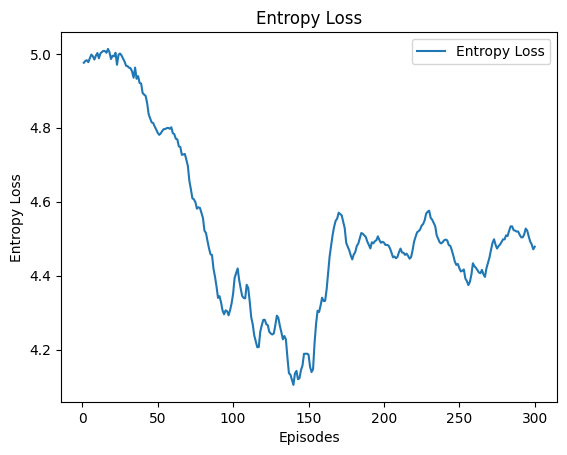

In [50]:
plt.plot(df_agents["episode"], df_agents['entropy'], label="Entropy Loss")
plt.xlabel("Episodes")
plt.ylabel("Entropy Loss")
plt.title("Entropy Loss")
plt.legend()
plt.show()

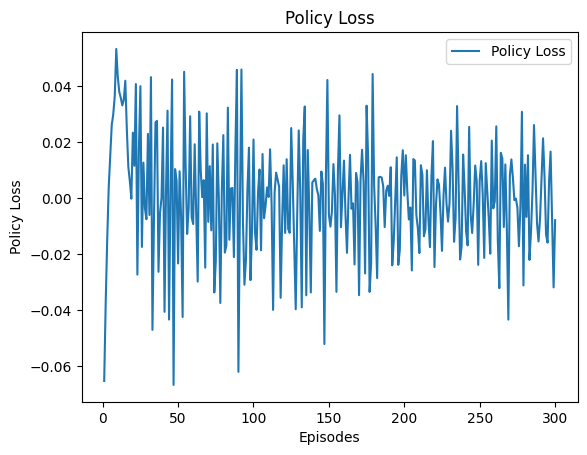

In [51]:
plt.plot(df_agents["episode"], df_agents['policy_loss'], label="Policy Loss")
plt.xlabel("Episodes")
plt.ylabel("Policy Loss")
plt.title("Policy Loss")
plt.legend()
plt.show()

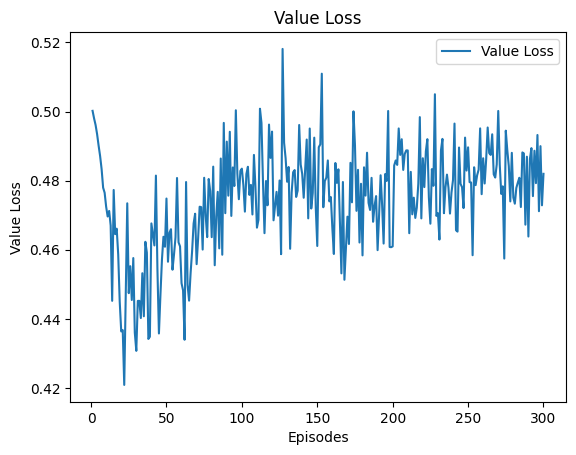

In [52]:
plt.plot(df_agents["episode"], df_agents['value_loss'], label="Value Loss")
plt.xlabel("Episodes")
plt.ylabel("Value Loss")
plt.title("Value Loss")
plt.legend()
plt.show()

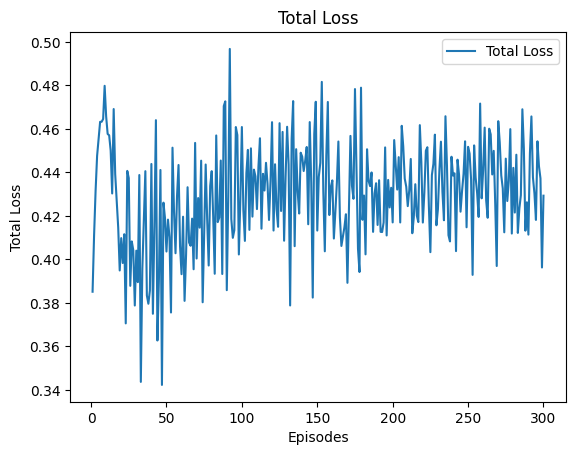

In [53]:
plt.plot(df_agents["episode"], df_agents['total_loss'], label="Total Loss")
plt.xlabel("Episodes")
plt.ylabel("Total Loss")
plt.title("Total Loss")
plt.legend()
plt.show()

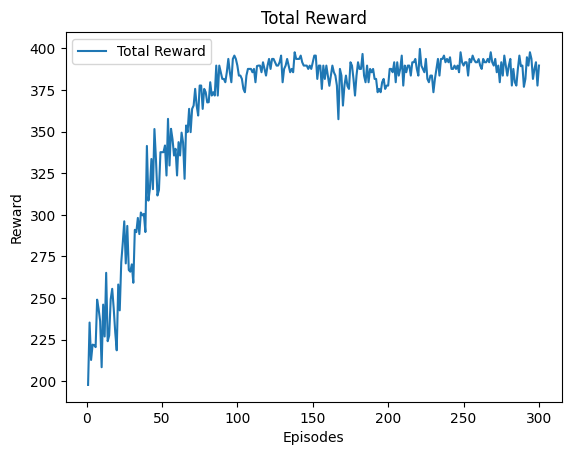

In [54]:
plt.plot(df_episode["episode"], df_episode['total_reward'], label="Total Reward")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Total Reward")
plt.legend()
plt.show()